In [1]:
pip install keras-tuner

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 3.9 MB/s eta 0:00:00


In [49]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error
import torch
import torch.nn as nn
import torch.nn.functional as F
import glob
import os
import kerastuner as kt

In [6]:
from tensorflow.python.client import device_lib

def get_available_devices():
    local_device_protos = device_lib.list_local_devices()
    return [x.name for x in local_device_protos]

print(get_available_devices())

['/device:CPU:0']


In [16]:
#load the data
df1 = pd.read_csv('/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv',header=0)
df2 = pd.read_csv('/content/PRSA_Data_Changping_20130301-20170228.csv',header=0)
df3 = pd.read_csv('/content/PRSA_Data_Dingling_20130301-20170228.csv',header=0)
df4 = pd.read_csv('/content/PRSA_Data_Dongsi_20130301-20170228.csv',header=0)
df5 = pd.read_csv('/content/PRSA_Data_Guanyuan_20130301-20170228.csv',header=0)
df6 = pd.read_csv('/content/PRSA_Data_Gucheng_20130301-20170228.csv',header=0)
df7 = pd.read_csv('/content/PRSA_Data_Huairou_20130301-20170228.csv',header=0)
df8 = pd.read_csv('/content/PRSA_Data_Nongzhanguan_20130301-20170228.csv',header=0)
df9 = pd.read_csv('/content/PRSA_Data_Shunyi_20130301-20170228.csv',header=0)
df10 = pd.read_csv('/content/PRSA_Data_Tiantan_20130301-20170228.csv',header=0)
df11 = pd.read_csv('/content/PRSA_Data_Wanliu_20130301-20170228.csv',header=0)
df12 = pd.read_csv('/content/PRSA_Data_Wanshouxigong_20130301-20170228.csv',header=0)
dataframes = [df1,df2,df3,df4,df5,df6,df7,df8,df9,df10,df11,df12]
df = pd.concat(dataframes,axis=0,ignore_index=True)
df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong


In [17]:
df.dtypes

No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

In [18]:
df.isnull().sum(axis=0)

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

In [19]:
#There are null values. Need to replace them with 0 or 'N/A'

#Fill in nulls with 0 for numeric or float columns
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = df[col].fillna(0)
#Fill in nulls with 'N/A' for onject columns columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna('N/A')

#check for nulls again
df.isnull().sum(axis=0)

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

In [20]:
#Convert cat features into numeric for training
cat_features = ['wd', 'station']
converted = pd.get_dummies(df[cat_features],drop_first=True,dtype=float)
converted.head()

,wd_ENE,wd_ESE,wd_N,wd_N/A,wd_NE,wd_NNE,wd_NNW,wd_NW,wd_S,wd_SE,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
df = df.drop(cat_features,axis=1)
df = pd.concat([df,converted],axis=1)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,station_Dingling,station_Dongsi,station_Guanyuan,station_Gucheng,station_Huairou,station_Nongzhanguan,station_Shunyi,station_Tiantan,station_Wanliu,station_Wanshouxigong
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
#split data into test and train sets
#we are trying to predict PM2.5

X = df.drop('PM2.5',axis=1)
y = df['PM2.5']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [23]:
#Normalize the features
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
%%time
tf.random.set_seed(42)
#Build the model
model1 = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(100, activation='relu'),
        tf.keras.layers.Dense(20, activation='relu'),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(1)
    ]
)
model1.compile(optimizer='adam',loss='mse')

history = model1.fit(X_train,y_train,batch_size=50,epochs=150,validation_data=(X_test,y_test),verbose=0)

CPU times: user 40min 22s, sys: 1min 45s, total: 42min 7s
Wall time: 38min 24s


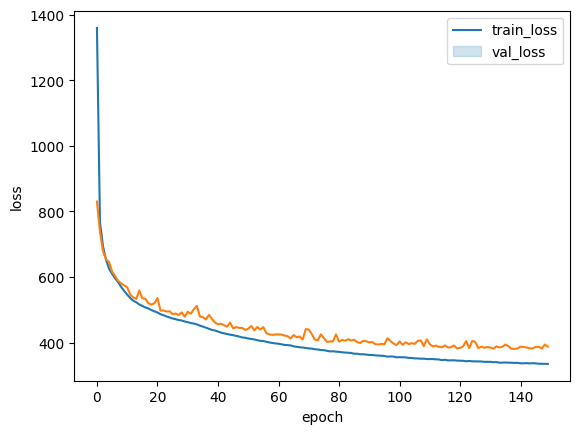

In [26]:
#Create line plot to see if data is underfitting or overfitting
train_history = pd.DataFrame(history.history)
train_history['epoch'] = history.epoch
sns.lineplot(x='epoch', y='loss', data=train_history)
sns.lineplot(x='epoch', y='val_loss', data=train_history)
plt.legend(labels=['train_loss', 'val_loss'])

### First trial result
I think that the data is underfitting the model due to the steady decrease into a negative slope

In [27]:
#Bring in the tuner and dropout

#define a function similar to the one in the lesson

def model_builder(hp):
  #Tune hyper parameters
  hp_units1 = hp.Int('units', min_value=20, max_value=50, step=5)
  hp_units2 = hp.Int('units', min_value=5, max_value=10, step=1)
  hp_dropout1 = hp.Float('rate', min_value = 0.2, max_value = 0.8, step = 0.1)
  #Build the model
  model2 = tf.keras.Sequential(
      [
          #input layer
          tf.keras.layers.Dense(100, activation='relu'),
          #hidden layer one
          tf.keras.layers.Dense(units=hp_units1,activation='relu'),
          tf.keras.layers.Dropout(rate=hp_dropout1),
          #hidden layer two
          tf.keras.layers.Dense(units=hp_units2, activation='relu'),
          tf.keras.layers.Dropout(rate=hp_dropout1)
      ]
  )

  #tune the learning rate as well
  hp_learning_rate = hp.Choice('learning_rate', values=[.01,.001,.001])

  #Compile the model
  model2.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
      loss='mse',
      metrics = [tf.keras.metrics.MeanSquaredError()]
  )
  return model2

In [34]:
#use the same tuner as the modules
tuner = kt.BayesianOptimization(
    model_builder,
    objective='val_loss',
    max_trials=5,
    directory= '/content',
    project_name='Project2_Carter_Daniel_tuner'
)

In [31]:
import IPython
#copy function from class to clear outputs
class ClearTrainingOutput(tf.keras.callbacks.Callback):
  def on_train_end(*args,**kwargs):
    IPython.display.clear_output(wait=True)

In [35]:
#Perform the search on the defined hyperparameter space by specifying the callback to clear the training outputs
tuner.search(X_train, y_train, epochs = 25, validation_data = (X_test,y_test), callbacks = [ClearTrainingOutput()])

Trial 5 Complete [00h 14m 23s]
val_loss: 2431.171875

Best val_loss So Far: 902.0271606445312
Total elapsed time: 01h 15m 37s


In [36]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]
#Use f-strings to format the outputs
print(f"""
The optimal number of units in the input layer =  {best_hps.get('units')}.
The optimal dropout rate in the input layer = {best_hps.get('rate')}
The optimal learning rate for the optimizer of Adam = {best_hps.get('learning_rate')}.
""")


The optimal number of units in the input layer =  50. 
The optimal dropout rate in the input layer = 0.2
The optimal learning rate for the optimizer of Adam = 0.001.



## Optimal Model
The optimal model will have two hidden layers with the following hyperparameters:
* Units: 50
* Dropout: 0.2
* Learning Rate: .001


## Pytorch

In [41]:
X = df.drop('PM2.5',axis=1)
y = df['PM2.5']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
X_train = torch.tensor(X_train.astype(np.float32))
y_train = torch.tensor(y_train.values.astype(np.float32).reshape(-1,1))
X_test = torch.tensor(X_test.astype(np.float32))
input_size=X_train.shape[1]
output_size=y_train.shape[1]
hidden_size = [20,10]

In [45]:
#Build the model similar to the one shown in class
class LinearRegressionModel(torch.nn.Module):
  def __init__(self, input_size,  hidden_size, output_size):
    super(LinearRegressionModel, self).__init__()
    self.hidden1 = torch.nn.Linear(input_size, hidden_size[0])
    self.hidden2 = torch.nn.Linear(hidden_size[0], hidden_size[1])
    self.predict = torch.nn.Linear(hidden_size[1], output_size)
  def forward(self, x):
      x = F.relu(self.hidden1(x))
      x = F.relu(self.hidden2(x))
      y_pred = self.predict(x)
      return y_pred

In [46]:
model = LinearRegressionModel(input_size, hidden_size, output_size)
l = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=.001)

In [51]:
%%time
#Run the model
torch.manual_seed(42)
np.random.seed(42)

num_epochs = 100
train_loss = [None]*num_epochs
val_loss=[None]*num_epochs
for epoch in range(num_epochs):
  y_pred = model(X_train.requires_grad_())
  loss = l(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  y_pred = model(X_test).detach().numpy()
  validation_loss = mean_squared_error(y_test,y_pred)
  train_loss[epoch] = loss.item()
  val_loss[epoch] = validation_loss

CPU times: user 19.7 s, sys: 4.67 s, total: 24.4 s
Wall time: 25.5 s


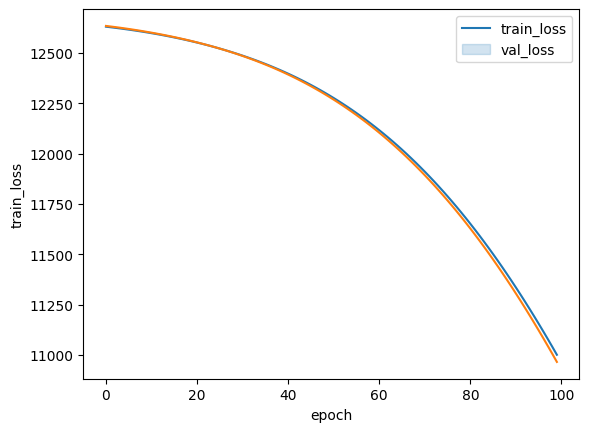

In [52]:
trainhistory = pd.DataFrame({'train_loss': train_loss, 'val_loss': val_loss, 'epoch':np.arange(num_epochs)})
sns.lineplot(x='epoch',y='train_loss',data=trainhistory)
sns.lineplot(x='epoch',y='val_loss',data=trainhistory)
plt.legend(labels=['train_loss','val_loss'])

## Results

The model is very badly underfitting. This is because of the steady decrease into a negative slope